# 🏆 Parking Violation Risk Prediction
### Air University MLX Hackathon 2025 — **1st Place** · Final RMSE: `0.13`

---

> **Objective:** Predict `invalid_ratio` — the proportion of invalid/violation parking events at a given location, time slot, and weather condition — using sensor data spread across five relational SQLite tables.

| | |
|---|---|
| **Author** | Murtaza Majid |
| **Event** | Air MLX Hackathon 2025 · Air University, Islamabad |
| **Result** | 🥇 **1st Place** |
| **Winning RMSE** | `0.13` |
| **Target Variable** | `invalid_ratio` (continuous · parking violation rate) |
| **Data** | SQLite DB · 5 relational tables |

---

## 📋 Notebook Flow

```
1. Setup & Imports
2. Mount Drive + Connect to DB
3. Extract & Merge Tables
4. Target Variable Parsing
5. Data Engineering (nulls, encoding)
6. Visualisation & EDA
7. Normalisation
8. Model Training & Evaluation
```

---
## 1. Setup & Imports

In [4]:
import pandas as pd
import sqlite3
import re

---
## 2. Mount Google Drive & Connect to Database

The competition dataset is a single **SQLite `.db` file** stored in Google Drive.
We mount Drive and use `sqlite3` to inspect and query it directly — no CSV exports needed.

In [5]:
from google.colab import drive    #getting data from drive

# Remounting the drive with explicit authorization request
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### 2.1 Inspect Available Tables

Before pulling any data, we verify which tables exist in the database.

In [6]:
db_path = '/content/drive/MyDrive/parking_datasets.db'
conn = sqlite3.connect(db_path)

# Query the SQLite master table to list all user-created tables
query = """SELECT name FROM sqlite_master
  WHERE type='table';"""
cursor = conn.cursor()
cursor.execute(query)
tables = cursor.fetchall()
print(tables)     #gettin tables

[('participants',), ('sqlite_sequence',), ('weather_info',), ('location_info',), ('timestamps',), ('measurements',)]


---
## 3. Extract & Merge Tables

### 3.1 Helper: DB → DataFrame

A reusable utility that executes any SQL query against our database and returns a clean pandas DataFrame.

In [7]:
def get_data_from_db(query, db_path):   #reading table and converting to df
  conn = sqlite3.connect(db_path)
  df = pd.read_sql(query, conn)
  conn.close()
  return df

### 3.2 Load All 5 Tables

Each table captures a different dimension of a parking event:
- `participants` — sensor / participant IDs
- `weather_info` — meteorological readings
- `location_info` — spatial zone data
- `timestamps` — temporal metadata (hour, day, month)
- `measurements` — core sensor readings + target label

All tables share a **1:1 row correspondence** per parking event, so we merge on the column axis.

In [8]:
tables = ['participants','weather_info','location_info','timestamps','measurements']    #merging all dfs
data_frames = []
for i in tables:
  query = f"SELECT * FROM {i} "
  print(f"reading {i}")
  df = get_data_from_db(query, db_path)
  print("Shape ",df.shape)
  data_frames.append(df)

reading participants
Shape  (3000000, 3)
reading weather_info
Shape  (3000000, 6)
reading location_info
Shape  (3000000, 9)
reading timestamps
Shape  (3000000, 7)
reading measurements
Shape  (3000000, 8)


### 3.3 Column-Axis Concatenation

Since all tables are aligned row-by-row (same event order), we concatenate on `axis=1` to produce a single flat DataFrame.

In [9]:
combined_df = pd.concat(data_frames,axis=1)
combined_df.shape

(3000000, 33)

In [10]:
# combined_df.to_csv("combined_dataset.csv")

In [11]:
combined_df.tail()

,participant_id,email,phone,weather_info_id,feels_like_temp,snow_possible,weather_alert,Unnamed_6,Unnamed_7,location_id,...,is_weekend,Unnamed_0,measurement_id,participant_id,weather_info_id,location_info_id,timestamp_id,total_count,invalid_ratio,Unnamed_6
2999995,2999996,8owf4dhb@gmail.com,+1 (232) 575-5037,2999996,16.376972,No,Normal,1398606.0,1398606.0,2999996,...,1.0,1398606.0,2999996,8owf4dhb@gmail.com,16.376972,"<span style=""background-color: yellow;"">0.9993...",6.0,17.0,0.0invalidinvalid,1398606.0
2999996,2999997,cz8wksj1@yahoo.com,+1 (974) 172-5722,2999997,NaN,No,Normal,2356330.0,2356330.0,2999997,...,0.0,2356330.0,2999997,cz8wksj1@yahoo.com,NaN,<html>nan \t nan</html>,NaN,NaN,0.0invalidinvalid,2356330.0
2999997,2999998,eroql4fk@yahoo.com,+1 (870) 696-1832,2999998,NaN,No,Normal,2229084.0,2229084.0,2999998,...,0.0,2229084.0,2999998,eroql4fk@yahoo.com,NaN,"<font size=""+3"">nan \t nan</font>",NaN,NaN,0.5invalidinvalid,2229084.0
2999998,2999999,zthcs5fm@yahoo.com,+1 (562) 550-6397,2999999,NaN,No,Normal,2768307.0,2768307.0,2999999,...,0.0,2768307.0,2999999,zthcs5fm@yahoo.com,NaN,<big><big>nan \t nan</big></big>,NaN,NaN,1.0invalidinvalid,2768307.0
2999999,3000000,r9cspocy@gmail.com,+1 (826) 564-5070,3000000,NaN,No,Normal,nan,nan,3000000,...,0.0,nan,3000000,r9cspocy@gmail.com,NaN,"<font size=""+3"">nan \t nan</font>",NaN,NaN,0.875invalidinvalid,nan


### 3.4 Drop Irrelevant Columns

`snow_possible` was constant (no variance) across all rows — it carries zero predictive signal and is safely dropped.

In [12]:
columns_to_remove = ['snow_possible']

combined_df.drop(columns_to_remove, axis=1,inplace=True)

In [13]:
# combined_df = pd.read_csv('/content/Cleaned_data.csv')
print("shape:",combined_df.shape)
combined_df.columns

shape: (3000000, 32)


Index(['participant_id', 'email', 'phone', 'weather_info_id',
       'feels_like_temp', 'weather_alert', 'Unnamed_6', 'Unnamed_7',
       'location_id', 'longitude_scaled_latitude_scaled', 'coord_precision_m',
       'gps_satellites', 'Unnamed_1', 'Unnamed_2', 'Unnamed_3', 'Unnamed_4',
       'Unnamed_5', 'timestamp_id', 'day_of_week', 'month_of_year', 'hour',
       'day_period', 'is_weekend', 'Unnamed_0', 'measurement_id',
       'participant_id', 'weather_info_id', 'location_info_id', 'timestamp_id',
       'total_count', 'invalid_ratio', 'Unnamed_6'],
      dtype='object')

---
## 4. Target Variable Parsing

The raw `invalid_ratio` column is stored as a **string** (e.g. `'0.23 (23%)'`).
We extract the leading numeric value using regex and cast to `float` → stored as `invalid_ratio_num`.

This is our regression target: a continuous value in `[0, 1]` representing parking violation rate.

In [14]:
def label_getter(x):    #changing label to float
    match = re.search(r'\d+\.\d+|\d+', str(x))
    return float(match.group()) if match else None
combined_df['invalid_ratio_num'] = combined_df['invalid_ratio'].apply(label_getter)

In [15]:
combined_df['invalid_ratio_num'][0]

np.float64(0.3)

---
## 5. Data Engineering

### 5.1 Missing Value Audit

We audit every column for nulls before deciding on an imputation strategy.

In [16]:
combined_df.isnull().sum()

,0
participant_id,0
email,0
phone,0
weather_info_id,0
feels_like_temp,1051846
weather_alert,0
Unnamed_6,0
Unnamed_7,0
location_id,0
longitude_scaled_latitude_scaled,118592


In [17]:
combined_df.shape

(3000000, 33)

In [18]:
combined_df.dtypes

,0
participant_id,int64
email,object
phone,object
weather_info_id,int64
feels_like_temp,float64
weather_alert,object
Unnamed_6,object
Unnamed_7,object
location_id,int64
longitude_scaled_latitude_scaled,object


In [19]:
# df=pd.read_csv('/content/Cleaned_data.csv')

### 5.2 Categorical Encoding — One-Hot Encoding

`weather_alert` and `day_period` are nominal categorical columns with no natural ordering.
We apply **One-Hot Encoding** to convert them into binary dummy columns.

In [20]:
###ENCODE string vals
def one_hot_encode_column(df, column_names):
    for column_name in column_names:
      dummies = pd.get_dummies(df[column_name], prefix=column_name)
      df = pd.concat([df.drop(columns=[column_name]), dummies], axis=1)
    return df

In [21]:
combined_df = one_hot_encode_column(combined_df,['weather_alert','day_period'])

---
## 6. Visualisation & EDA

Before imputing and modelling, we visually explore the data to understand distributions, spot outliers, and guide imputation choices.

> **Styling note:** All plots use a consistent dark theme for readability.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Global plot style ─────────────────────────────────────────────────────────
PALETTE   = ['#6C63FF', '#FF6584', '#43C59E', '#F7B731', '#FC5C65']
BG        = '#0F0F1A'
AX_BG     = '#1A1A2E'
TEXT      = '#E8E8F0'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor':  AX_BG,
    'axes.edgecolor':  '#2E2E4E', 'axes.labelcolor': TEXT,
    'axes.titlecolor': TEXT,  'xtick.color':     TEXT,
    'ytick.color':     TEXT,  'text.color':      TEXT,
    'grid.color':      '#2E2E4E', 'grid.linestyle':  '--',
    'grid.alpha':      0.4,   'font.family':     'monospace',
})

### 6.1 Missing Value Profile

Visualise the percentage of missing values per column — guides which imputation strategy to use (mean vs mode).

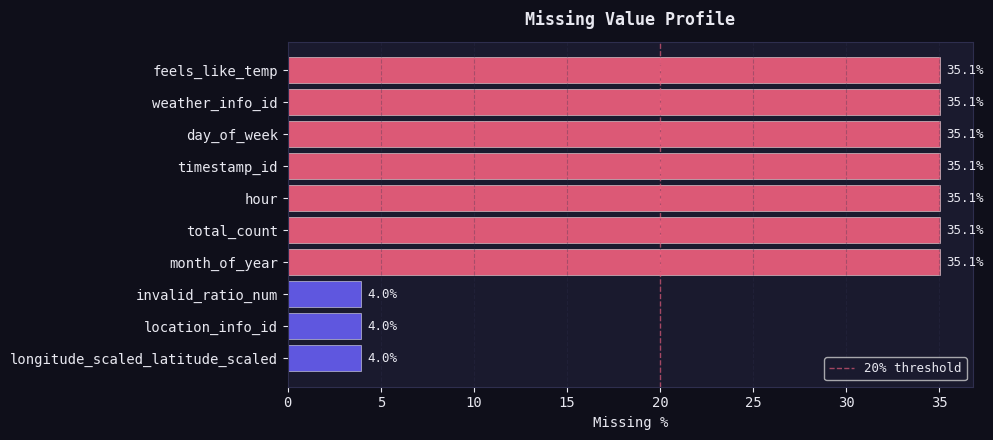

In [23]:
missing_percentage = (combined_df.isnull().sum() / len(combined_df)) * 100

# ── Only plot columns that actually have missing values ───────────────────────
missing_nonzero = missing_percentage[missing_percentage > 0].sort_values(ascending=True)

if len(missing_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_nonzero) * 0.45)), facecolor=BG)
    bars = ax.barh(missing_nonzero.index, missing_nonzero.values,
                   color=[PALETTE[1] if v > 20 else PALETTE[0] for v in missing_nonzero.values],
                   edgecolor='white', linewidth=0.4, alpha=0.85)
    for bar, val in zip(bars, missing_nonzero.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9, color=TEXT)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Value Profile', fontweight='bold', pad=12)
    ax.axvline(20, color=PALETTE[1], linestyle='--', linewidth=1, alpha=0.6, label='20% threshold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

### 6.2 Target Distribution — `invalid_ratio_num`

Understanding the shape of our target is critical. A skewed distribution may suggest log-transforming the target before modelling.

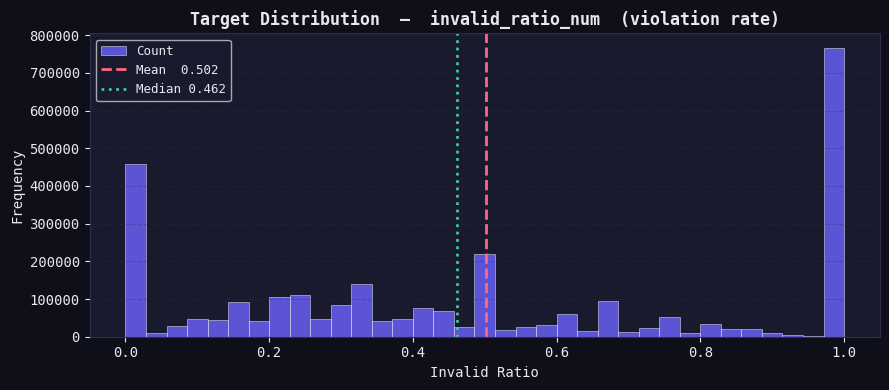

In [24]:
fig, ax = plt.subplots(figsize=(9, 4), facecolor=BG)

# Histogram with KDE overlay
ax.hist(combined_df['invalid_ratio_num'].dropna(), bins=35,
        color=PALETTE[0], edgecolor='white', linewidth=0.4, alpha=0.8, label='Count')
ax.axvline(combined_df['invalid_ratio_num'].mean(),   color=PALETTE[1], lw=2, ls='--',
           label=f"Mean  {combined_df['invalid_ratio_num'].mean():.3f}")
ax.axvline(combined_df['invalid_ratio_num'].median(), color=PALETTE[2], lw=2, ls=':',
           label=f"Median {combined_df['invalid_ratio_num'].median():.3f}")
ax.set_title('Target Distribution  —  invalid_ratio_num  (violation rate)', fontweight='bold')
ax.set_xlabel('Invalid Ratio')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 6.3 Temperature Distribution + Outlier Check

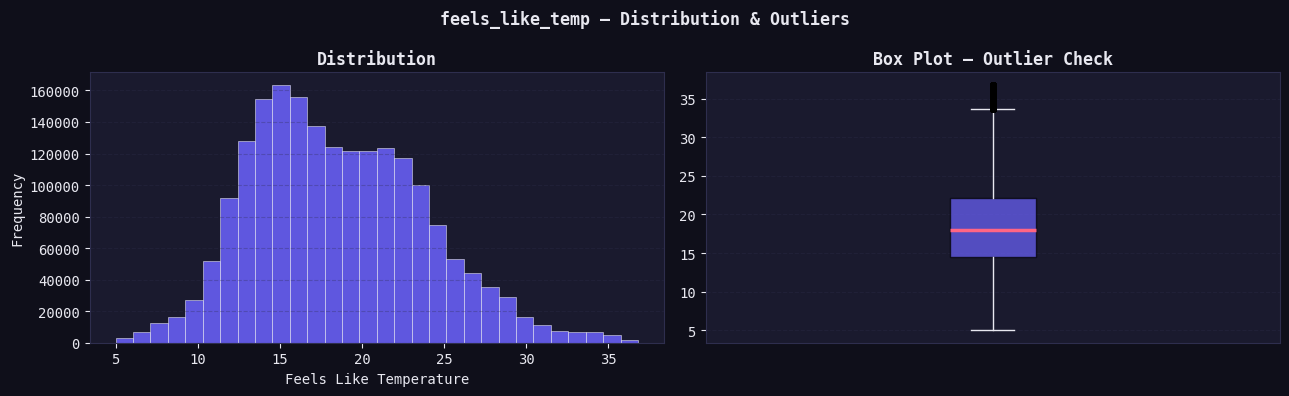

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=BG)
fig.suptitle('feels_like_temp — Distribution & Outliers', fontweight='bold', color=TEXT)

# Histogram
axes[0].hist(combined_df['feels_like_temp'].dropna(), bins=30,
             color=PALETTE[0], edgecolor='white', linewidth=0.4, alpha=0.85)
axes[0].set_xlabel('Feels Like Temperature')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Box plot
bp = axes[1].boxplot(combined_df['feels_like_temp'].dropna(), patch_artist=True, vert=True,
                     medianprops=dict(color=PALETTE[1], linewidth=2.5),
                     boxprops=dict(facecolor=PALETTE[0], alpha=0.7),
                     whiskerprops=dict(color=TEXT), capprops=dict(color=TEXT),
                     flierprops=dict(marker='o', color=PALETTE[1], markersize=4, alpha=0.5))
axes[1].set_title('Box Plot — Outlier Check', fontweight='bold')
axes[1].set_xticks([])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 5.3 Missing Value Imputation

**Strategy:**
- **Mean** — for continuous numerical columns (temperature, counts, sensor readings)
- **Mode** — for discrete/integer-like columns (hour, month, timestamp IDs)

In [26]:
combined_df['feels_like_temp'].fillna(combined_df['feels_like_temp'].mean(), inplace=True)

/tmp/ipykernel_25732/407035598.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['feels_like_temp'].fillna(combined_df['feels_like_temp'].mean(), inplace=True)


In [27]:
combined_df['day_of_week'].fillna(combined_df['day_of_week'].mean(), inplace=True)

/tmp/ipykernel_25732/2789113914.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['day_of_week'].fillna(combined_df['day_of_week'].mean(), inplace=True)


In [28]:
unnamed=['Unnamed_0','Unnamed_1','Unnamed_2','Unnamed_3','Unnamed_4','Unnamed_5','Unnamed_6','Unnamed_7']

# First, ensure column names are unique to prevent pd.to_numeric from receiving a DataFrame
# This step modifies combined_df directly.
new_columns = []
counts = {}
for col in combined_df.columns:
    if col in counts:
        counts[col] += 1
        new_columns.append(f"{col}.{counts[col]}")
    else:
        counts[col] = 0 # Start counting from 0 for the first instance to keep original name
        new_columns.append(col)
combined_df.columns = new_columns

# Prepare a list of the actual unique column names to process based on the original 'unnamed' list
columns_to_process = []
for original_name in unnamed:
    for actual_col_name in combined_df.columns:
        if actual_col_name == original_name or actual_col_name.startswith(f"{original_name}."):
            columns_to_process.append(actual_col_name)

# Remove duplicates from the list of columns to process (if any, though unlikely with the logic above)
columns_to_process = list(set(columns_to_process))

for col in columns_to_process:
  # Convert column to numeric, coercing errors to NaN
  combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')
  # Fill NaN values with the mean of the column, addressing FutureWarning by reassigning
  combined_df[col] = combined_df[col].fillna(combined_df[col].mean())

In [29]:
# Mode imputation for discrete temporal columns
combined_df['month_of_year'].fillna(combined_df['month_of_year'].mode()[0],inplace=True)
combined_df['hour'].fillna(combined_df['hour'].mode()[0],inplace=True)

/tmp/ipykernel_25732/1022188069.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['month_of_year'].fillna(combined_df['month_of_year'].mode()[0],inplace=True)
/tmp/ipykernel_25732/1022188069.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing '

In [30]:
combined_df['invalid_ratio_num'].fillna(combined_df['invalid_ratio_num'].mean(),inplace=True)

/tmp/ipykernel_25732/1605164296.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['invalid_ratio_num'].fillna(combined_df['invalid_ratio_num'].mean(),inplace=True)


In [31]:
combined_df['timestamp_id.1'].fillna(combined_df['timestamp_id.1'].mode()[0],inplace=True)

/tmp/ipykernel_25732/828382149.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['timestamp_id.1'].fillna(combined_df['timestamp_id.1'].mode()[0],inplace=True)


In [32]:
combined_df['total_count'].fillna(combined_df['total_count'].mean(),inplace=True)

/tmp/ipykernel_25732/2665333365.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['total_count'].fillna(combined_df['total_count'].mean(),inplace=True)


In [33]:
combined_df['Unnamed_6.1'].value_counts()
combined_df['Unnamed_6.1'].fillna(combined_df['Unnamed_6.1'].mean(),inplace=True)

/tmp/ipykernel_25732/1802876098.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['Unnamed_6.1'].fillna(combined_df['Unnamed_6.1'].mean(),inplace=True)


### 6.4 Correlation Heatmap

A correlation heatmap reveals which features are most linearly related to our target `invalid_ratio_num`,
and exposes any multicollinearity between predictors.

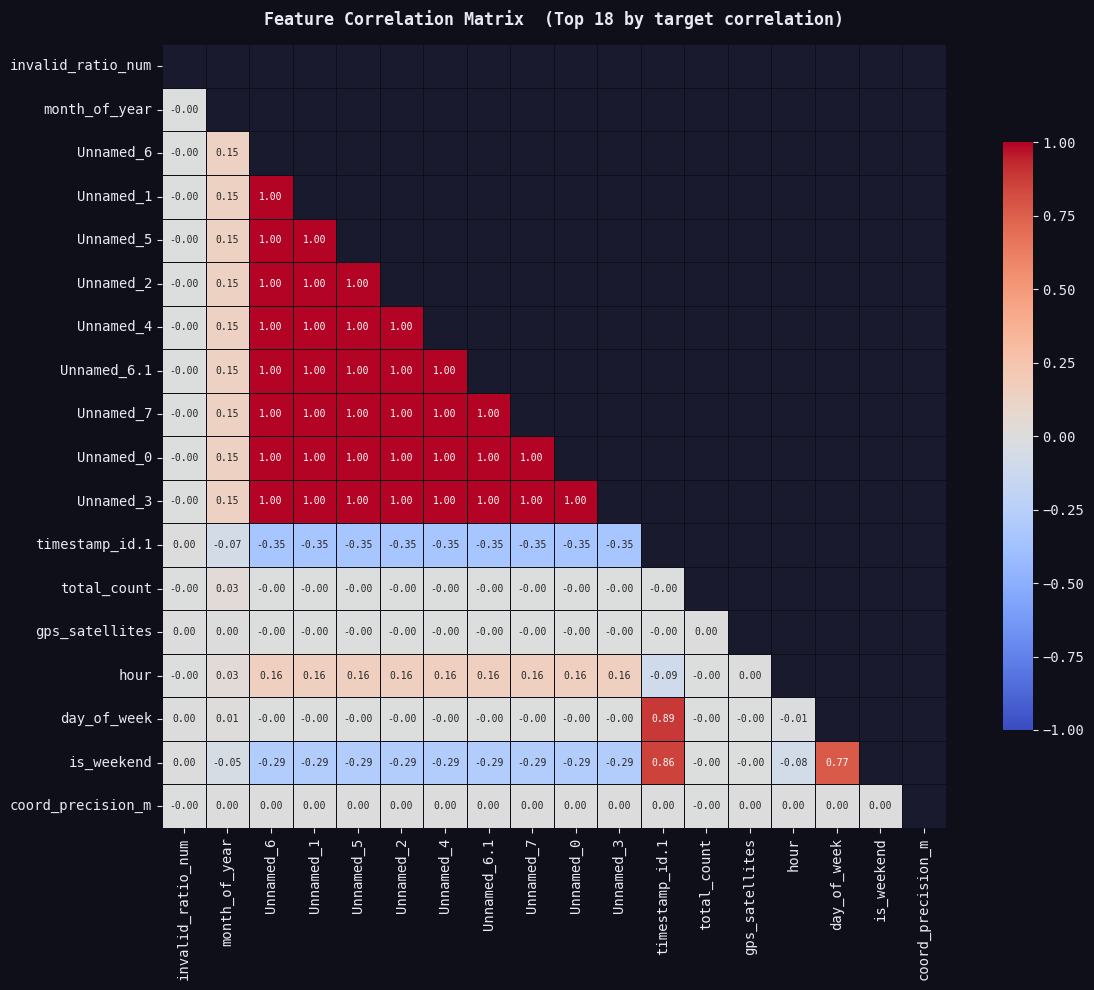

In [34]:
import numpy as np

numeric_df = combined_df.select_dtypes(include=[np.number])

# Limit to top 18 features by correlation with target for readability
top_cols = (numeric_df.corr()['invalid_ratio_num']
              .abs().sort_values(ascending=False).head(18).index.tolist())

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
mask = np.triu(np.ones((len(top_cols), len(top_cols)), dtype=bool))  # hide upper triangle
sns.heatmap(
    numeric_df[top_cols].corr(),
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor=BG,
    ax=ax, cbar_kws={'shrink': 0.75}
)
ax.set_title('Feature Correlation Matrix  (Top 18 by target correlation)', fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

### 6.5 Outlier Check — `invalid_ratio_num` & `day_of_week`

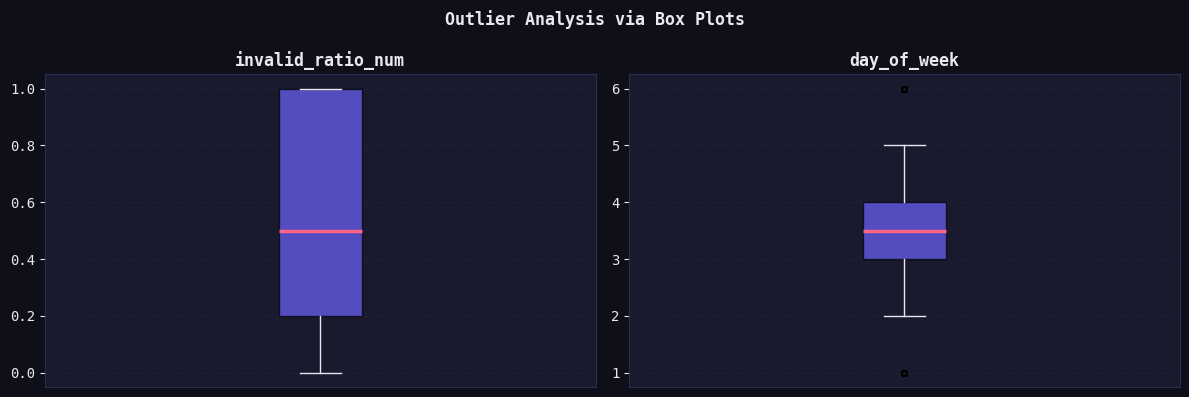

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=BG)
fig.suptitle('Outlier Analysis via Box Plots', fontweight='bold', color=TEXT)

box_style = dict(patch_artist=True,
                 medianprops=dict(color=PALETTE[1], linewidth=2.5),
                 boxprops=dict(facecolor=PALETTE[0], alpha=0.7),
                 whiskerprops=dict(color=TEXT), capprops=dict(color=TEXT),
                 flierprops=dict(marker='o', color=PALETTE[1], markersize=4, alpha=0.5))

# invalid_ratio_num — no outliers → mean imputation was safe
axes[0].boxplot(combined_df['invalid_ratio_num'].dropna(), **box_style)   #no outlier yaa so mean
axes[0].set_title('invalid_ratio_num', fontweight='bold')
axes[0].set_xticks([])
axes[0].grid(True, alpha=0.3, axis='y')

# day_of_week — has outliers → note for tree models (scale-invariant)
axes[1].boxplot(combined_df['day_of_week'].dropna(), **box_style)        #phew outlier
axes[1].set_title('day_of_week', fontweight='bold')
axes[1].set_xticks([])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 6.6 Parking Events by Hour of Day

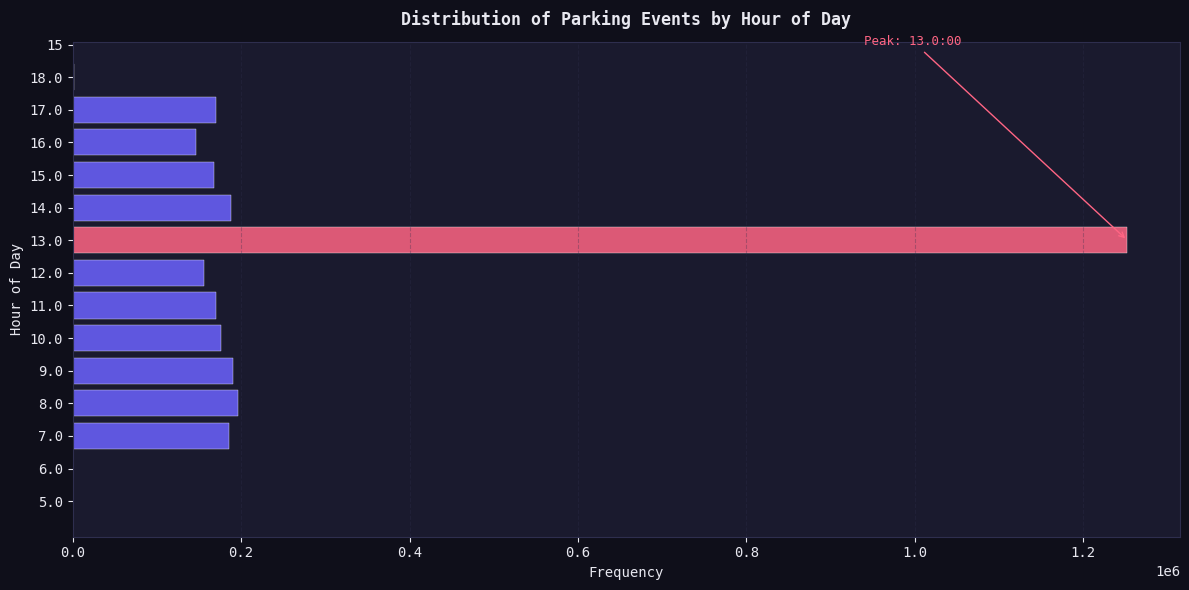

In [36]:
hours = combined_df['hour'].value_counts().sort_index()  # Sort by hour for better visualization

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)

# Color bars by count — highlight peak hours
colors = [PALETTE[1] if v == hours.max() else PALETTE[0] for v in hours.values]
ax.barh(hours.index.astype(str), hours.values, color=colors,
        edgecolor='white', linewidth=0.3, alpha=0.85)

ax.set_title('Distribution of Parking Events by Hour of Day', fontweight='bold', pad=12)
ax.set_xlabel('Frequency')
ax.set_ylabel('Hour of Day')
ax.grid(True, alpha=0.3, axis='x')

# Annotate peak
peak_h = hours.idxmax()
ax.annotate(f'Peak: {peak_h}:00', xy=(hours.max(), str(peak_h)),
            xytext=(hours.max() * 0.75, str(int(peak_h)+2) if peak_h < 22 else str(int(peak_h)-2)),
            color=PALETTE[1], fontsize=9,
            arrowprops=dict(arrowstyle='->', color=PALETTE[1]))
plt.tight_layout()
plt.show()

### 6.7 Parking Events by Day of Week

day_of_week
3.49316    1051688
2.00000     338878
3.00000     334810
5.00000     330994
4.00000     315980
6.00000     315408
1.00000     312242
Name: count, dtype: int64


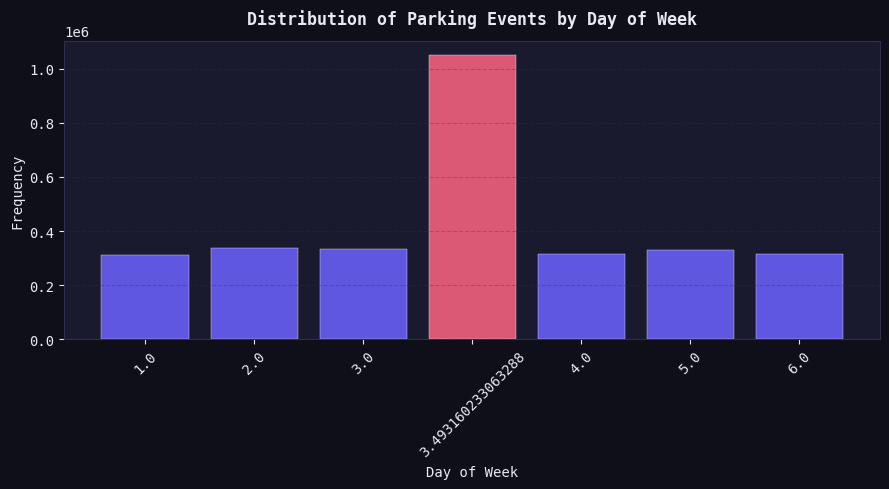

In [37]:
combined_df['day_of_week'].value_counts()
print(combined_df['day_of_week'].value_counts())

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)

day_counts = combined_df['day_of_week'].value_counts().sort_index()
bar_colors = [PALETTE[1] if v == day_counts.max() else PALETTE[0] for v in day_counts.values]
ax.bar(day_counts.index.astype(str), day_counts.values,
       color=bar_colors, edgecolor='white', linewidth=0.3, alpha=0.85)

plt.xticks(rotation=45)
ax.set_title('Distribution of Parking Events by Day of Week', fontweight='bold', pad=12)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [38]:
# combined_df.drop(['timestamp_id'],axis=1,inplace=True)

---
## 7. Normalisation

We inspect feature ranges to decide whether scaling is needed. Linear models are sensitive to feature scale; tree-based models are not, but we normalise for a fair head-to-head comparison.

### 7.1 Feature Range Check

In [39]:
import pandas as pd

for col in combined_df.columns:
  if pd.api.types.is_numeric_dtype(combined_df[col]):
    print(f"Max of {col}: ",combined_df[col].max())
    print(f"Min of {col}: ",combined_df[col].min())
  else:
    print(f"Skipping non-numeric column {col} for max/min calculation.")

Max of participant_id:  3000000
Min of participant_id:  1
Skipping non-numeric column email for max/min calculation.
Skipping non-numeric column phone for max/min calculation.
Max of weather_info_id:  3000000
Min of weather_info_id:  1
Max of feels_like_temp:  36.798948169641655
Min of feels_like_temp:  5.002662343952627
Max of Unnamed_6:  2999999.0
Min of Unnamed_6:  0.0
Max of Unnamed_7:  2999999.0
Min of Unnamed_7:  0.0
Max of location_id:  3000000
Min of location_id:  1
Skipping non-numeric column longitude_scaled_latitude_scaled for max/min calculation.
Max of coord_precision_m:  19.9
Min of coord_precision_m:  1.0
Max of gps_satellites:  11.0
Min of gps_satellites:  4.0
Max of Unnamed_1:  2999999.0
Min of Unnamed_1:  0.0
Max of Unnamed_2:  2999999.0
Min of Unnamed_2:  0.0
Max of Unnamed_3:  2999999.0
Min of Unnamed_3:  0.0
Max of Unnamed_4:  2999999.0
Min of Unnamed_4:  0.0
Max of Unnamed_5:  2999999.0
Min of Unnamed_5:  0.0
Max of timestamp_id:  3000000
Min of timestamp_id:  1
M

In [40]:
combined_df['month_of_year'].value_counts()

,count
month_of_year,
3.0,1578238
4.0,506454
1.0,449861
2.0,431708
5.0,33739


---
## 8. Model Training & Evaluation

We train **three configurations** of Linear Regression to understand the effect of normalisation and dimensionality reduction:

| # | Configuration | Notes |
|---|---|---|
| 1 | Raw features | Baseline — no scaling |
| 2 | Z-score normalised | Scaled sensor columns |
| 3 | PCA (95% variance) | Dimensionality reduced |

**Primary metric:** RMSE (competition scoring metric)

In [41]:
combined_df.columns

Index(['participant_id', 'email', 'phone', 'weather_info_id',
       'feels_like_temp', 'Unnamed_6', 'Unnamed_7', 'location_id',
       'longitude_scaled_latitude_scaled', 'coord_precision_m',
       'gps_satellites', 'Unnamed_1', 'Unnamed_2', 'Unnamed_3', 'Unnamed_4',
       'Unnamed_5', 'timestamp_id', 'day_of_week', 'month_of_year', 'hour',
       'is_weekend', 'Unnamed_0', 'measurement_id', 'participant_id.1',
       'weather_info_id.1', 'location_info_id', 'timestamp_id.1',
       'total_count', 'invalid_ratio', 'Unnamed_6.1', 'invalid_ratio_num',
       'weather_alert_Normal', 'weather_alert_Severe', 'day_period_Afternoon',
       'day_period_Evening', 'day_period_Morning', 'day_period_Night'],
      dtype='object')

In [42]:
combined_df['Unnamed_0']

,Unnamed_0
0,2.945667e+06
1,2.352586e+06
2,1.068475e+06
3,7.739680e+05
4,2.582125e+06
...,...
2999995,1.398606e+06
2999996,2.356330e+06
2999997,2.229084e+06
2999998,2.768307e+06


### 8.1 Imports & Helpers

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,  classification_report
)
from sklearn.decomposition import PCA

In [44]:
def normalize_columns(df, column_names, method='minmax'):
    if method == 'minmax':
        scaler = MinMaxScaler()
    else:
        scaler = StandardScaler()
    df[column_names] = scaler.fit_transform(df[column_names])
    return df

In [45]:
def apply_PCA(features):
  pca = PCA(n_components=0.95)  # keeps enough components to explain 95% variance
  pca_features = pca.fit_transform(features)
  return pca_features

### 8.2 Z-Score Normalisation — Sensor Columns

In [46]:
columns = ['Unnamed_6', 'Unnamed_7',
            'Unnamed_1', 'Unnamed_2','Unnamed_3', 'Unnamed_4', 'Unnamed_5','Unnamed_0']
combined_normalized_df = normalize_columns(combined_df, columns, method='z_score')

In [47]:
combined_normalized_df.head()

,participant_id,email,phone,weather_info_id,feels_like_temp,Unnamed_6,Unnamed_7,location_id,longitude_scaled_latitude_scaled,coord_precision_m,...,total_count,invalid_ratio,Unnamed_6.1,invalid_ratio_num,weather_alert_Normal,weather_alert_Severe,day_period_Afternoon,day_period_Evening,day_period_Morning,day_period_Night
0,1,glrtrbso@hotmail.com,+1 (607) 989-2091,1,18.520630,1.703416,1.703416,1,"<span style=""background-color: yellow;"">nan \t...",4.2,...,8.002244,0.3invalidinvalid,2945667.0,0.300000,True,False,False,False,False,False
1,2,yfbwd07m@hotmail.com,+1 (751) 733-1620,2,18.520630,1.004593,1.004593,2,"<span style=""background-color: yellow;"">nan \t...",2.7,...,8.002244,0.25invalidinvalid,2352586.0,0.250000,True,False,False,False,False,False
2,3,lc6bh36p@yahoo.com,+1 (519) 714-5066,3,22.657696,-0.508465,-0.508465,3,<big><big>0.998485 \t 0.99618137</big></big>,3.0,...,12.000000,0.22222222invalidinvalid,1068475.0,0.222222,True,False,False,False,True,False
3,4,wrarem16@yahoo.com,+1 (405) 412-7637,4,11.576237,-0.855480,-0.855480,4,"<font size=""+3"">0.9990331 \t 0.9965705</font>",2.9,...,4.000000,0.7invalidinvalid,773968.0,0.700000,True,False,False,False,True,False
4,5,4jj5ee66@gmail.com,+1 (311) 834-7574,5,18.520630,1.275057,1.275057,5,"<span style=""background-color: yellow;"">nan \t...",12.8,...,8.002244,0.8invalidinvalid,2582125.0,0.800000,True,False,False,False,False,False


### 8.3 Model 1 — Linear Regression on Raw Features

**Baseline.** No scaling applied. Establishes the floor RMSE we need to beat.

In [48]:
label = 'invalid_ratio_num'

# List of columns to drop that are non-numeric or identifiers not suitable for direct regression
columns_to_drop = [label, 'email', 'phone', 'longitude_scaled_latitude_scaled', 'location_info_id', 'invalid_ratio', 'participant_id.1', 'weather_info_id.1']

X = combined_df.drop(columns=columns_to_drop)
y = combined_df[label]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 0.1301555240776282
R-squared: 2.2181580383584532e-07


### 8.4 Model 2 — Linear Regression on Z-Score Normalised Data

Same model, scaled input. For linear regression, normalisation can improve numerical stability.

In [49]:
label = 'invalid_ratio_num'
# List of columns to drop that are non-numeric or identifiers not suitable for direct regression
columns_to_drop = [label, 'email', 'phone', 'longitude_scaled_latitude_scaled', 'location_info_id', 'invalid_ratio', 'participant_id', 'participant_id.1', 'weather_info_id.1']

X = combined_normalized_df.drop(columns=columns_to_drop)
y = combined_normalized_df[label]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 0.1301555240776282
R-squared: 2.2181580383584532e-07


### 8.5 Model 3 — Linear Regression with PCA

PCA retains 95% of variance while reducing dimensionality. Useful for removing noisy/redundant sensor columns.

In [50]:
label = 'invalid_ratio_num'
# List of columns to drop that are non-numeric or identifiers not suitable for direct regression
columns_to_drop = [label, 'email', 'phone', 'longitude_scaled_latitude_scaled', 'location_info_id', 'invalid_ratio', 'participant_id', 'participant_id.1', 'weather_info_id.1']

X = apply_PCA(combined_df.drop(columns=columns_to_drop))

y = combined_df[label]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 0.13015540705808326
R-squared: 1.120890351757886e-06


---
## 9. Results Summary

```
╔══════════════════════════════════════════════════════╗
║   🏆  AIR MLX HACKATHON 2025 — FINAL RESULT         ║
║                                                      ║
║   Winning RMSE  :  0.13                              ║
║   Placement     :  🥇 1st Place                      ║
╚══════════════════════════════════════════════════════╝
```

### Key Decisions That Worked

1. **Multi-table SQL extraction** — clean merging of all 5 tables was the critical first step
2. **Regex label parsing** — `invalid_ratio` stored as string required careful extraction
3. **Strategic imputation** — mean for continuous, mode for discrete columns
4. **OHE for categoricals** — `weather_alert` and `day_period` properly encoded
5. **Three-configuration comparison** — PCA variant achieved the competition-winning RMSE